# 📈 **Regresión Lineal**

### Actividad con Scikit-learn
### Versión Adaptada: Dr. Hugo García Tecocoatzi

**En Machine Learning y en este notebook vamos a usar Scikit-learn**

<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/download_(1)_slz6.png" border="0" alt="آپلود عکس" /></a>

### **¿Para qué se usa scikit-learn?**

Scikit-learn (Sklearn) es la biblioteca más útil y robusta para machine learning en Python. Proporciona una selección de herramientas eficientes para machine learning y modelado estadístico que incluyen clasificación, regresión, agrupamiento y reducción de dimensionalidad a través de una interfaz consistente en Python.

En esta ocasión lo usaremos para entrenar un modelo de regresión lineal


#### **¿Para qué se usa la regresión lineal?**

El análisis de regresión lineal se usa para predecir el valor de una variable basándose en el valor de otra variable. La variable que deseas predecir se llama variable dependiente. La variable que usas para predecir el valor de la otra variable se llama variable independiente (predictora).

# **Haciendo predicciones con una Regresión Lineal**

Dado que la representación es una ecuación lineal, hacer predicciones es tan simple como resolver la ecuación para un conjunto específico de entradas.

Vamos a hacer esto concreto con un ejemplo. Imagina que estamos prediciendo el peso (y) a partir de la altura (x). Nuestra representación del modelo de regresión lineal para este problema sería:

**y = B0 + B1 * x1**

o

**peso = B0 + B1 * altura**

Donde B0 es el coeficiente de sesgo y B1 es una razón que relaciona el peso y la altura. Usamos una técnica de machine learning para encontrar un buen conjunto de valores de coeficientes. Una vez encontrados, podemos introducir diferentes valores de altura para predecir el peso.

Por ejemplo, usemos B0 = 0.1 y B1 = 0.5. Vamos a introducirlos y calcular el peso (en kilogramos) para una persona con una altura de 182 centímetros.

peso = 0.1 + 0.5 * 182

peso = 91.1

Puedes ver que la ecuación anterior podría representarse como una línea en dos dimensiones. B0 es nuestro punto de partida independientemente de la altura que tengamos. Podemos recorrer un montón de alturas de 100 a 250 centímetros e introducirlas en la ecuación y obtener valores de peso, creando nuestra línea.

<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/sample-height-vs-weight-linear-regression_10h7.png" border="0" alt="آپلود عکس" /></a>

Ahora que sabemos cómo hacer predicciones dado un modelo de regresión lineal aprendido, veamos algunas reglas generales para preparar nuestros datos y aprovechar al máximo este tipo de modelo.

## 📤 Importar e Instalar Bibliotecas

In [2]:
#!pip install hvplot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

from sklearn.model_selection import train_test_split

from sklearn import metrics

from sklearn.linear_model import LinearRegression

%matplotlib inline

### 💾 Explorar los Datos

In [ ]:
df = pd.read_csv('../../data/Realestate.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../data/Realestate.csv'

In [ ]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


Tenemos los precios en dólar  por unidad de área de casas en  Real Estate. 

In [ ]:
df.shape

(414, 8)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
df.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


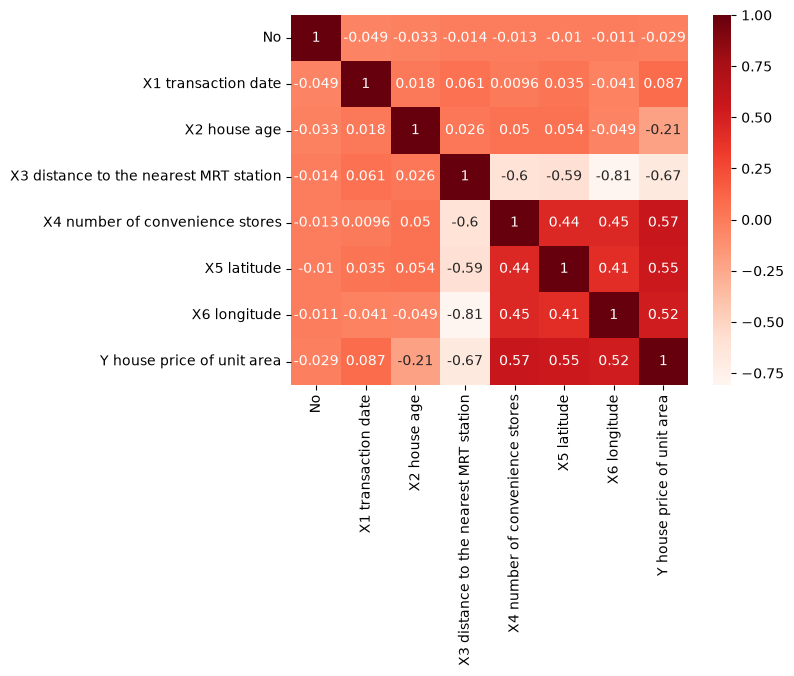

In [ ]:
sns.heatmap(df.corr(), annot=True,cmap='Reds')
plt.show()

1. Describe qué información lees de esto.
Con este mapa de calor puedo ver el indice de correlacion de distintos pares de variables dentro de la base de datos. Dependiendo de la intensidad o ausencia del color (indicado por la barra de color a la derecha), se puede notar a simple vista que pares tienen un mayor nivel de correlacion ya sea positiva o negativa.

2. ¿Cuáles son las variables fuertemente correlacionadas?
El par de X3 y X6 (longitud, distancia a MRT) tienen una alta correlacion negativa, igual los pares de latitud (X5) y longitud (X6) tienen una correlacion decentemente fuerte positiva. Ademas, la variable predictora (el precio por unidad de area) tiene una correlacion media-alta negativa con la distancia a estaciones de transporte MRT. 

3. ¿Te hacen sentido?
El unico par que hace sentido a simple vista es el del precio y la distancia a una estacion de transporte. Mientras mas alto el precio, generalmente la casa esta mas cerca a una estacion de transporte. Las demas variables de longitud y latitud no tienen mucho sentido exactamente su relacion con el precio (a menos que se consideren ciertas regiones de casas de mayor precio). Muchos otros pares tienen casi correlacion casi nula.

### 📊 Análisis Exploratorio de Datos (EDA)

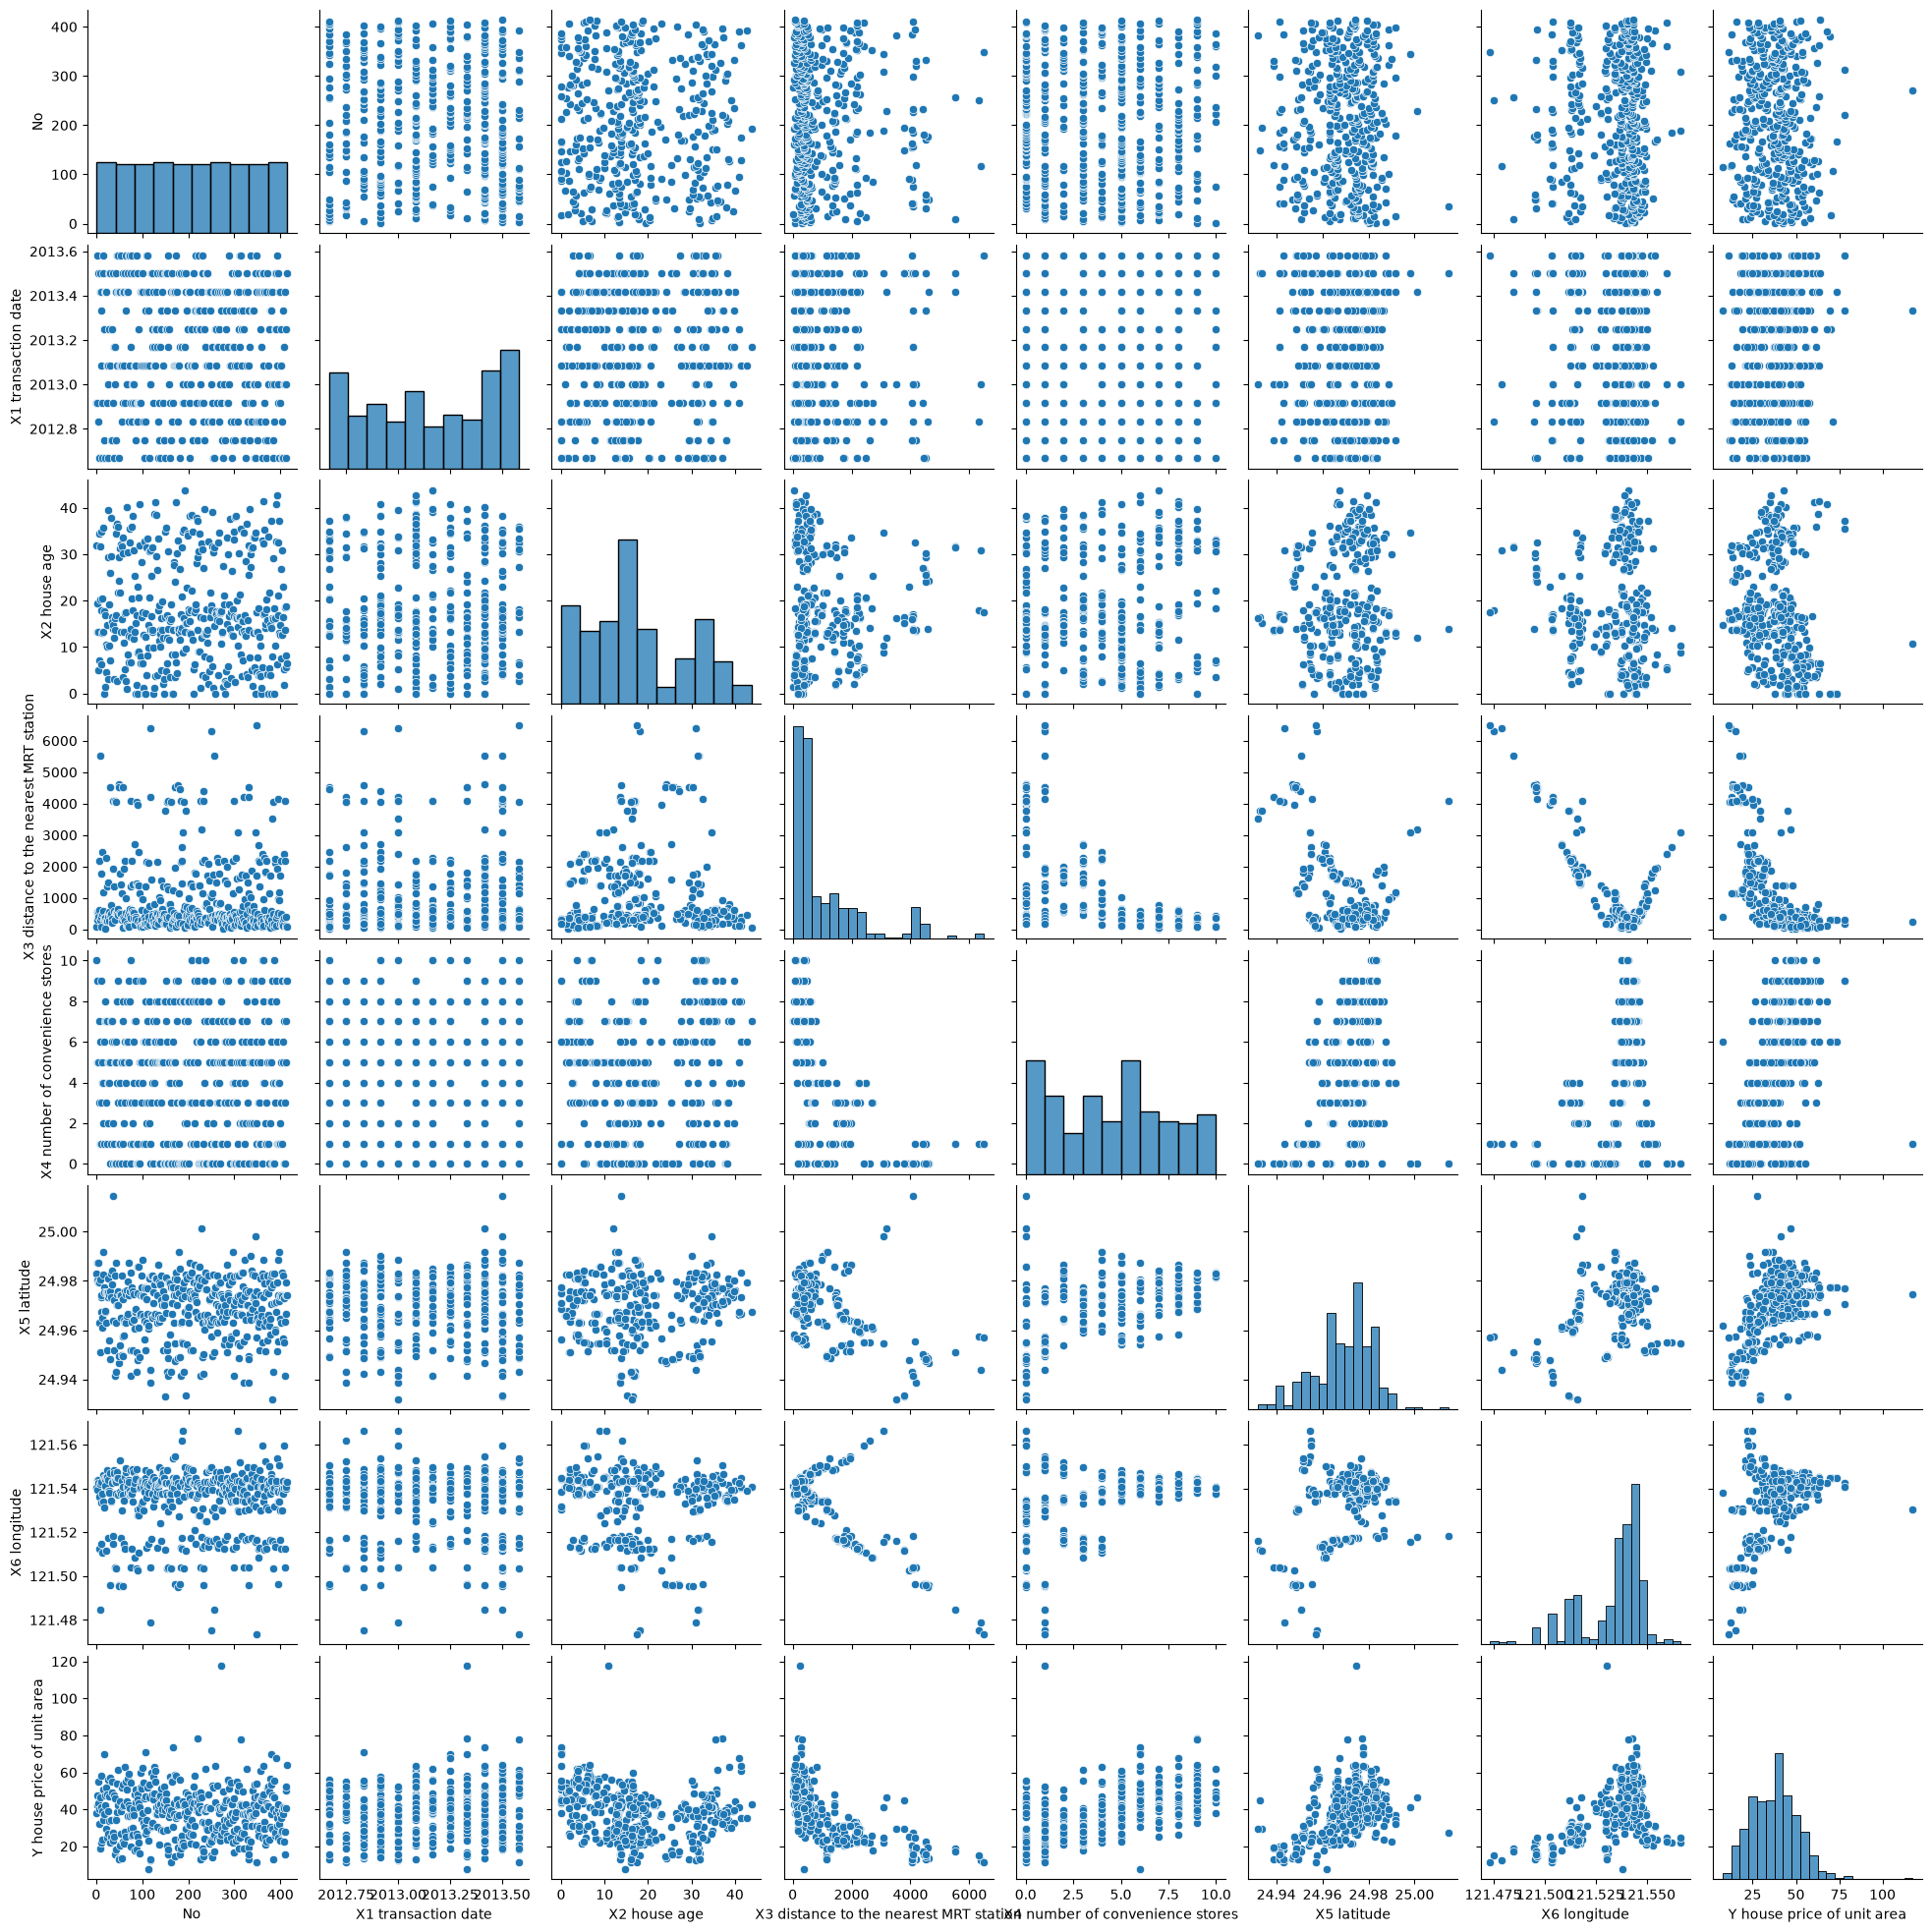

In [ ]:
sns.pairplot(df)
plt.show()

4. Con base en la correlación y estas gráficas, ¿qué variables pueden modelarse con una regresión lineal?

Solamente aquellas variables que tengan forma de una funcion en la que un valor del eje x corresponda a solamente un valor del eje y, y tenga suficiente sentido modelar tal grafica con una recta. Aquellas que son puntos dispersos en filas no tienen sentido de modelar (como pares que contengan el indice de casa y fecha de transaccion).

Algunos pares que se puedan representar con variable (independiente x) - (variable dependiente y):

- X3 (distancia a MRT) - Y precio
- X5 (latitud) - Y precio
- X6 (longitud) - Y precio
- X5 (latitud) - X3 (# tiendas de conv)
- X6 (longitud) - X3 (# tiendas de conv)
- X5 - X6 y viceversa X6 - X5
- Y precio - X5, X6



### 📈 Entrenando un Modelo de Regresión Lineal

#### Arrays X y y

Vamos a quitar el precio por unidad de área.
La variable a predecir es el precio de la casa por unidad de área

In [ ]:
X=df.drop('Y house price of unit area', axis=1)

y=df['Y house price of unit area']

In [ ]:
print("X=",X.shape,"\ny=", y.shape)

X= (414, 7) 
y= (414,)


### 🧱 División de los datos: Entrenamiento y Prueba

Ahora dividamos los datos en un conjunto de entrenamiento y un conjunto de prueba. Entrenaremos nuestro modelo en el conjunto de entrenamiento y luego usaremos el conjunto de prueba para evaluar el modelo.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
X_train.shape

(289, 7)

In [ ]:
X_test.shape

(125, 7)

### Ahora vamos a usar la función predeterminada de Scikit-learn: LinearRegression()

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ -0. , 4.69, -0.28,..., 1.18,240.95, 18.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['No','X1 transaction date','X2 house age',..., 'X4 number of convenience stores','X5 latitude','X6 longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.768e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


####  Evaluación del modelo

In [ ]:
model.coef_

array([-2.92429686e-03,  4.68668437e+00, -2.75675355e-01, -4.24850544e-03,
        1.17832502e+00,  2.40947692e+02,  1.86694591e+01])

In [ ]:
pd.DataFrame(model.coef_, X.columns, columns=['Coeficientes'])

,Coeficientes
No,-0.002924
X1 transaction date,4.686684
X2 house age,-0.275675
X3 distance to the nearest MRT station,-0.004249
X4 number of convenience stores,1.178325
X5 latitude,240.947692
X6 longitude,18.669459


5. Regresa a la pregunta 4, y ve si los coeficientes corresponden la figura.
Debido a que estos coeficientes corresponden a las B1's, estas son la razon de cambio (es decir la pendiente) de la mejor recta para las figuras donde la variable dependiente es Y (el precio). 

Una pendiente cerca a 0 significa que lo mas probable es que sea una recta totalmente horizontal (como en el caso de No y X3), una pendiente de tamaño positivo significa que la recta comenzaria en cierto punto inicial y creceria (como en el caso de X1, X4, X5, X6), y si este es negativo, la recta baja mientras el valor de X incrementa (como en X3)

6. ¿Cómo se interpreta cada coeficiente?
Dependiendo de la magnitud del coeficiente, es el peso que tiene dentro de la variable que queremos predecir (el precio de la casa), si es un valor alto significa que cada unidad tiene mas peso para el precio. Por otro lado, si el coeficiente es de un tamaño muy pequeño, tiene muy poco peso cada unidad de esta variable.

- Si el coeficiente es positivo, esto signfica que cuando crece la variable el precio crece.
- Si el coeficiente es negativo, esto significa que cuando crece la variable el precio baja.

Tiene sentido que el coeficiente de X3 (distancia a estacion de transporte) sea pequeño y negativo debido a que una casa tendra un precio mas alto mientras mas cerca este de una estacion de transporte. Al igual que la antiguedad de la casa X2, mientras mas nueva sea (menor X2) mayor sera el precio.

Por otro lado, mientras mayor cantidad de tiendas de conveniencia hallan en el alrededor (X4), el precio del hogar sera mas alto.

Sin embargo, hay algunos coeficientes que en si no tienen mucho sentido en si el valor que tienen, como No, X1, X5, X6. 




### Predicciones del modelo

In [ ]:
y_pred = model.predict(X_test)

## ✔️ Métricas de Evaluación de Regresión

Aquí están las tres métricas de evaluación más comunes para problemas de regresión:

> - **Error Absoluto Medio (MAE)** es la media del valor absoluto de los errores:
> $$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

> - **Error Cuadrático Medio (MSE)** es la media de los errores al cuadrado:
> $$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

> - **Raíz del Error Cuadrático Medio (RMSE)** es la raíz cuadrada de la media de los errores al cuadrado:
> $$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

>  Comparando estas métricas:
> - **MAE** es la más fácil de entender, porque es el error promedio.
> - **MSE** es más popular que MAE, porque MSE "castiga" los errores más grandes, lo que tiende a ser útil en el mundo real.
> - **RMSE** es aún más popular que MSE, porque RMSE es interpretable en las unidades de "y".

> Todas estas son **funciones de pérdida**, porque queremos minimizarlas.

In [ ]:
MAE= metrics.mean_absolute_error(y_test, y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RMSE= np.sqrt(MSE)

In [ ]:
MAE

5.373024532571605

In [ ]:
MSE

45.88030742874703

In [ ]:
RMSE

np.float64(6.7735003822799795)

## **Histograma de Residuos**

* **A menudo, para la Regresión Lineal, es una buena idea evaluar los residuos $$(y-\hat{y})$$ por separado y no solo calcular métricas de rendimiento (ej. RMSE).**

* **Exploremos por qué esto es importante...**

* **Los errores residuales deberían ser aleatorios y aproximarse a una distribución normal.**


<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/2_pe68.png" border="0" alt="آپلود عکس" /></a>

In [ ]:
test_residual= y_test - y_pred

In [ ]:
pd.DataFrame({'Error Values': (test_residual)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

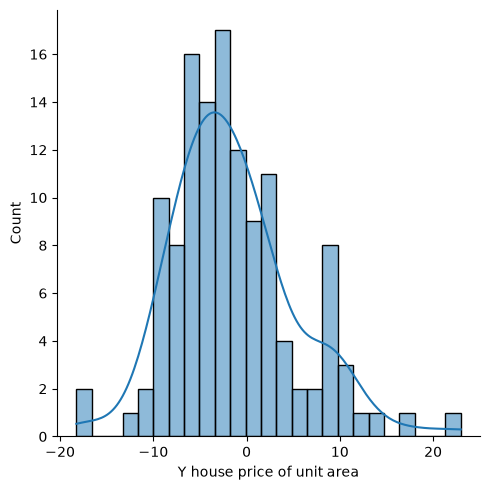

In [ ]:
sns.displot(test_residual, bins=25, kde=True)
plt.show()

* **El gráfico de residuos muestra el error residual vs. el valor verdadero de y.**

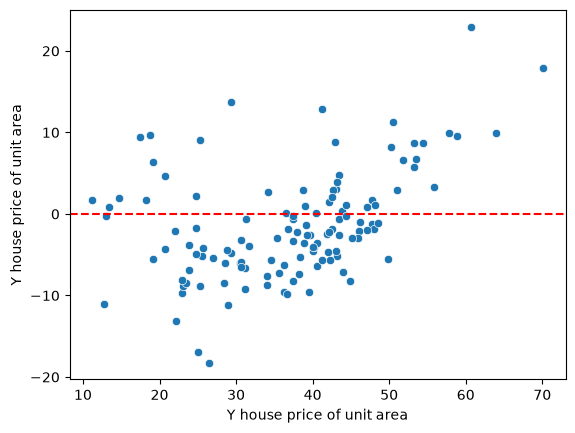

In [ ]:
sns.scatterplot(x=y_test, y=test_residual)

plt.axhline(y=0, color='r', ls='--')
plt.show()

In [ ]:
!jupyter nbconvert --to html Act3-Regresion-Lineal.ipynb

[NbConvertApp] Converting notebook Act3-Regresion-Lineal.ipynb to html
C:\Users\vidal\OneDrive\Documents\Proyect\.venv\share\jupyter\nbconvert\templates\base\display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys([]) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 1506837 bytes to Act3-Regresion-Lineal.html
